In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import itertools
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)
from mapie.metrics import (regression_coverage_score,
                           regression_mean_width_score)
from mapie.subsample import BlockBootstrap
from mapie.regression import MapieTimeSeriesRegressor
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from mapie.regression import MapieRegressor
from sklearn.model_selection import KFold
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
import math

/Users/minosbatakis/anaconda3/envs/uni/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Group-based

Individual - 10094
Split‑CP MAE=0.454, Coverage=96.67%, Width (avg)=2.540, mae_cal: 0.414
ACI MAE=0.454, Coverage=83.33%, Width (avg)=1.523, mae_cal: 0.414


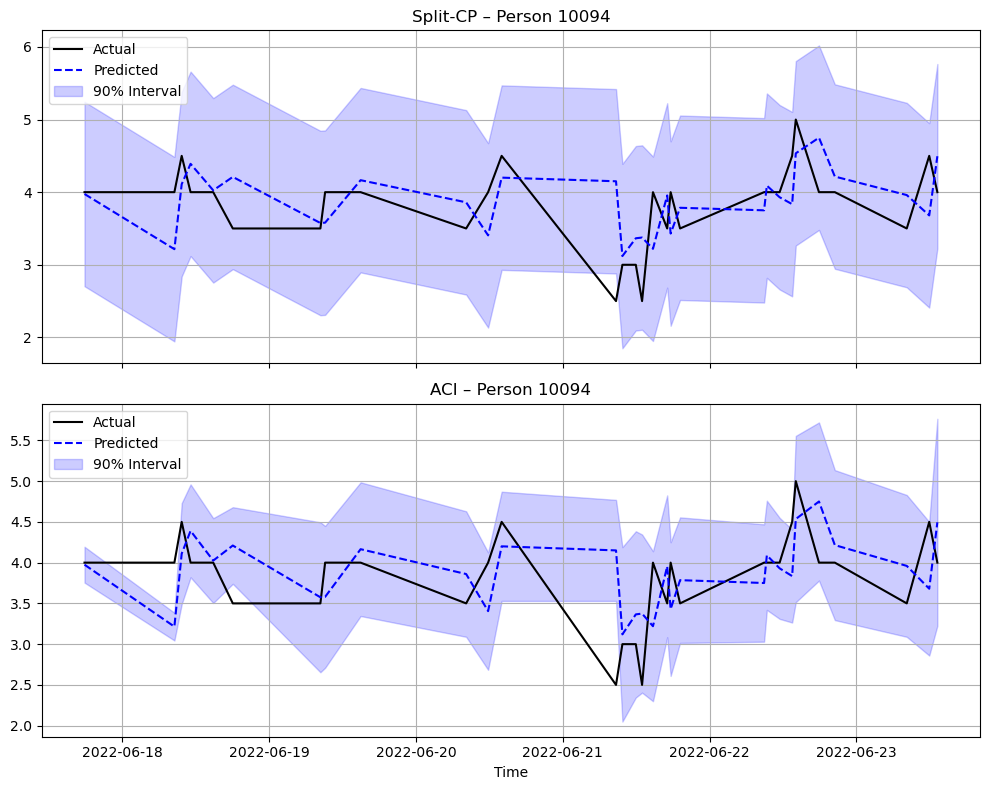

####################################################################################################
Individual - 43823
Split‑CP MAE=0.565, Coverage=100.00%, Width (avg)=3.410, mae_cal: 0.875
ACI MAE=0.565, Coverage=87.10%, Width (avg)=2.424, mae_cal: 0.875


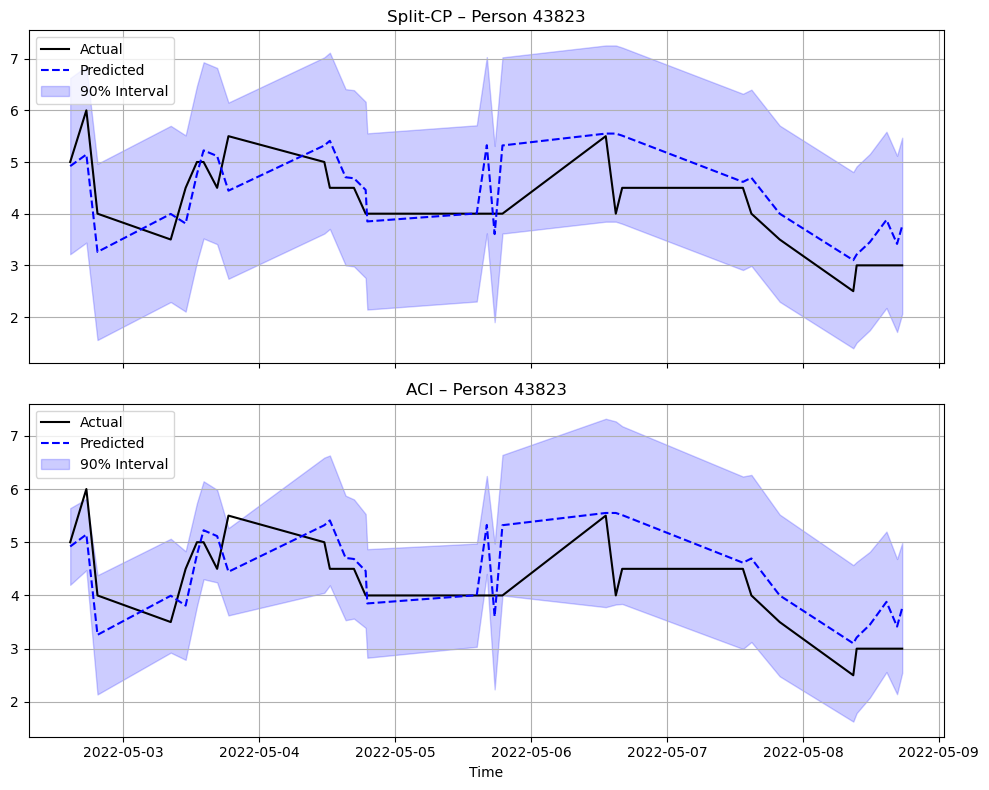

####################################################################################################
Individual - 43892
Split‑CP MAE=0.714, Coverage=100.00%, Width (avg)=3.910, mae_cal: 0.885
ACI MAE=0.714, Coverage=84.00%, Width (avg)=2.960, mae_cal: 0.885


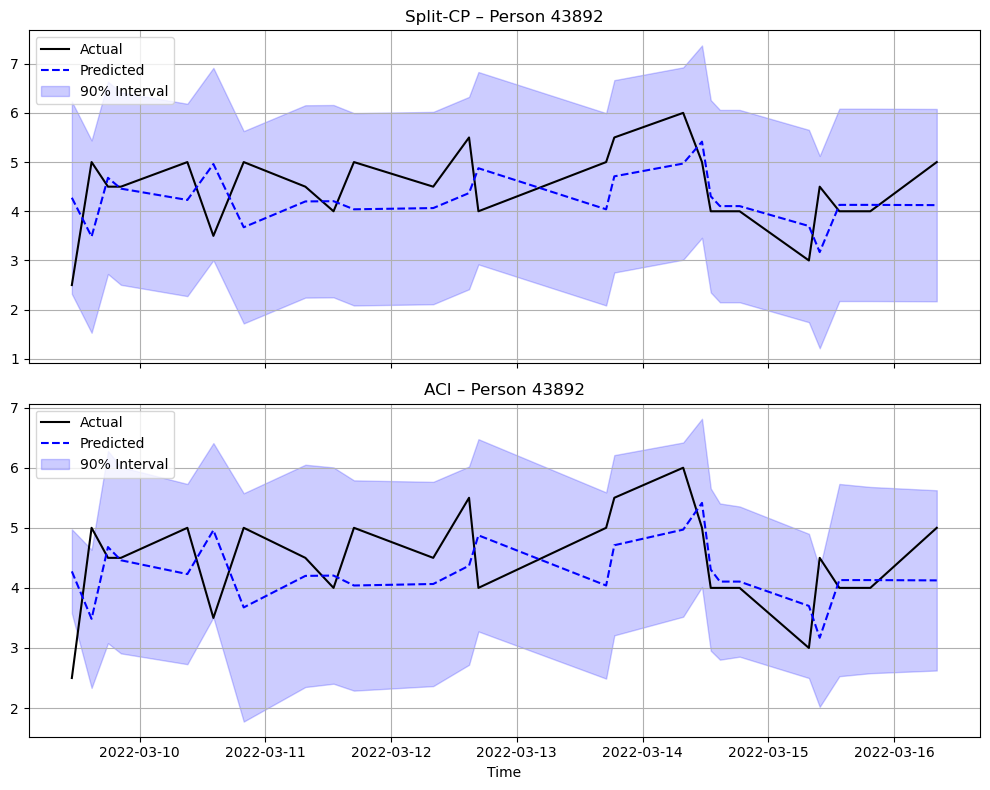

####################################################################################################
Individual - 56138.0
Split‑CP MAE=1.161, Coverage=68.29%, Width (avg)=3.170, mae_cal: 0.822
ACI MAE=1.161, Coverage=80.49%, Width (avg)=4.184, mae_cal: 0.822


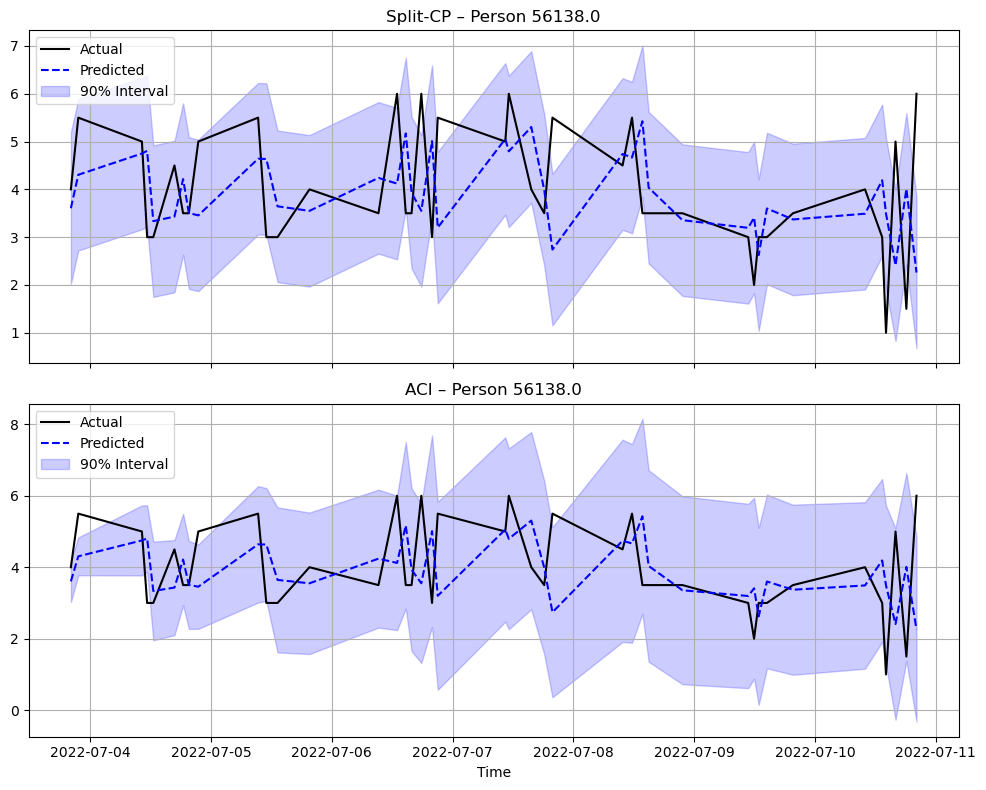

####################################################################################################
5.00%% - Split CP, Coverage=7.32%, Width (avg)=0.161
5.00%% - ACI CP, Coverage=14.74%, Width (avg)=0.325
####################################################################################################
10.00%% - Split CP, Coverage=12.04%, Width (avg)=0.255
10.00%% - ACI CP, Coverage=19.06%, Width (avg)=0.426
####################################################################################################
15.00%% - Split CP, Coverage=18.06%, Width (avg)=0.378
15.00%% - ACI CP, Coverage=22.96%, Width (avg)=0.507
####################################################################################################
20.00%% - Split CP, Coverage=22.74%, Width (avg)=0.479
20.00%% - ACI CP, Coverage=26.51%, Width (avg)=0.591
####################################################################################################
25.00%% - Split CP, Coverage=27.63%, Width (avg)=0.592
25.00%% - A

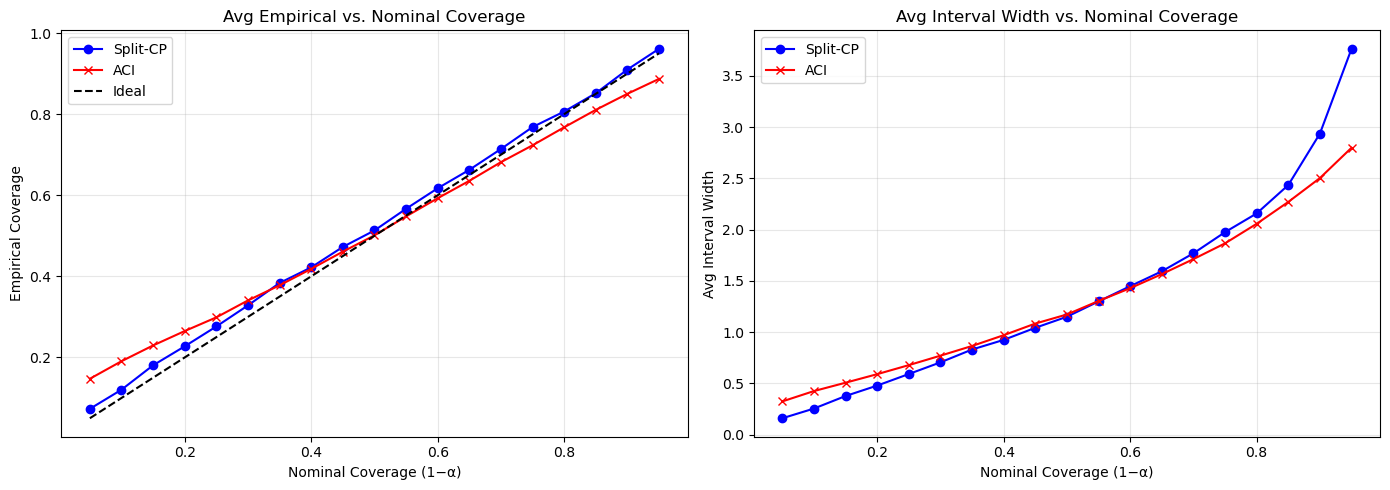

In [6]:
# Assumes df_train, df_cal, df_test, df_feat, FEATURE_COLS, TARGET are already defined
# 1) Load and sort raw data
df = pd.read_csv("df12_ind187.csv")   
df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])
df = df.sort_values(["Name", "datetime"]).reset_index(drop=True)

# Identify the 12 mood columns (exclude identifiers)
exclude = {"Name","Duration", "Date", "Time", "datetime"}
mood_vars = [c for c in df.columns if c not in exclude]

# 2) Compute features on the full series per individual (so lags only look backward)
def make_features_full(df, mood_vars, lags=[1]):
    """
    On the entire df (all individuals), compute:
      - Cyclical time (hour_sin, hour_cos, dow_sin, dow_cos)
      - days_since_start (per individual)
      - lag1/lag2/lag3 for each mood var (per individual)
    Drop any rows with NaN in those new features or in the raw mood_vars.
    """
    df2 = df.copy()
    # 2A) Cyclical time
    df2["hour"] = df2["datetime"].dt.hour
    df2["dow"]  = df2["datetime"].dt.dayofweek
    df2["hour_rad"] = 2 * np.pi * df2["hour"] / 24
    df2["dow_rad"]  = 2 * np.pi * df2["dow"]  / 7
    df2["hour_sin"] = np.sin(df2["hour_rad"])
    df2["hour_cos"] = np.cos(df2["hour_rad"])
    df2["dow_sin"]  = np.sin(df2["dow_rad"])
    df2["dow_cos"]  = np.cos(df2["dow_rad"])
    # 2B) days_since_start per individual
    df2["days_since_start"] = (df2["datetime"] - 
                               df2.groupby("Name")["datetime"].transform("min")
                              ).dt.days
    # 2C) lag features
    for var in mood_vars:
        for lag in lags:
            df2[f"{var}_lag{lag}"] = df2.groupby("Name")[var].shift(lag)
    # 2D) Drop rows with any NaN in features or raw moods - we could fillna() here as well
    feat_cols = ["hour_sin","hour_cos","dow_sin","dow_cos","days_since_start"] \
                + [f"{v}_lag{l}" for v in mood_vars for l in lags]
    df2 = df2.dropna(subset=feat_cols + mood_vars).reset_index(drop=True)
    return df2

df_feat = make_features_full(df, mood_vars, lags=[1])

train_idx, cal_idx, test_idx = [], [], []

for pid, grp in df_feat.groupby("Name"):
    # grp is sorted by datetime because df_feat inherits the order
    n = len(grp)
    n_train = int(0.60 * n)
    n_cal   = int(0.20 * n)
    # Ensure at least 1 row in each partition if possible
    if n_train < 1:
        n_train = 0
    if n_cal < 1 and (n - n_train) > 1:
        n_cal = 1
    # Compute index positions
    idx = grp.index.to_numpy()
    train_ids = idx[:n_train]
    cal_ids   = idx[n_train : n_train + n_cal]
    test_ids  = idx[n_train + n_cal : ]
    train_idx.extend(train_ids.tolist())
    cal_idx.extend(cal_ids.tolist())
    test_idx.extend(test_ids.tolist())

df_train = df_feat.loc[train_idx].reset_index(drop=True)
df_cal   = df_feat.loc[cal_idx].reset_index(drop=True)
df_test  = df_feat.loc[test_idx].reset_index(drop=True)

# 4) Prepare X and y for each split (example with TARGET="PA")
TARGET = "Self_esteem"
exclude_cols = {"Name", "Duration", "Date", "Time", "datetime"} | set(mood_vars)
FEATURE_COLS = [c for c in df_feat.columns if c not in exclude_cols]


# 1) Train global model
rf_global = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_global.fit(df_train[FEATURE_COLS], df_train[TARGET])


# Helper for manual ENBPI quantile
def bootstrap_quantile(residuals, alpha, bs):
    qs = []
    for cal_idx, _ in bs.split(residuals.reshape(-1,1)):
        qs.append(np.quantile(residuals[cal_idx], 1-alpha, interpolation="higher"))
    return np.median(qs)

# 2) Plot time series for three individuals at 90% (alpha=0.10)
plot_ids = [10094, 43823, 43892,56138.0]
alpha_plot = 0.10
bs_blocks = BlockBootstrap(n_resamplings=500, length=12, overlapping=False, random_state=42)

for pid in plot_ids:
    print(f"Individual - {pid}")
    df_cal_i = df_cal[df_cal["Name"] == pid]
    df_test_i = df_test[df_test["Name"] == pid]
    if df_cal_i.empty or df_test_i.empty: continue
    
    X_cal = df_cal_i[FEATURE_COLS].values 
    y_cal = df_cal_i[TARGET].values
    X_test = df_test_i[FEATURE_COLS].values 
    y_test = df_test_i[TARGET].values
    times = df_test_i["datetime"].values
    
    # Split-CP
    m_s = MapieRegressor(rf_global, method="plus", cv="prefit")
    m_s.fit(X_cal, y_cal)
    y_pred_s, pis_s = m_s.predict(X_test, alpha=alpha_plot)
    lo_s, up_s = pis_s[:,0,0], pis_s[:,1,0]
    
    
    # ACI
    cal_res = np.abs(y_cal - rf_global.predict(X_cal))
    q_t = np.median(cal_res)
    gamma = 0.5
    lo_a, up_a, preds_a = [], [], rf_global.predict(X_test)
    for yhat, ytrue in zip(preds_a, y_test):
        lo_a.append(yhat - q_t)
        up_a.append(yhat + q_t)
        r = abs(ytrue - yhat)
        miss = int(r > q_t)          # 1 if we missed, 0 if we covered
        q_t += gamma * (miss - alpha_plot)
        q_t = max(q_t, 0.0)          
    lo_a, up_a = np.array(lo_a), np.array(up_a)
    
    # Plot
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    for ax, (label, y_pred, lo, up) in zip(axes, [
        ("Split‑CP",    y_pred_s,  lo_s, up_s),
        ("ACI",         preds_a,    lo_a, up_a),
    ]):
        mae = mean_absolute_error(y_test, y_pred)
        coverage= np.mean((y_test >= lo) & (y_test <= up))
        width = np.mean(up - lo)
        mae_cal = mean_absolute_error(y_cal, rf_global.predict(X_cal))
        print(f"{label} MAE={mae:.3f}, Coverage={coverage:.2%}, Width (avg)={width:.3f}, mae_cal: {mae_cal:.3f}")
        
        ax.plot(times, y_test, 'k-', label="Actual")
        ax.plot(times, y_pred, 'b--', label="Predicted")
        ax.fill_between(times, lo, up, color='b', alpha=0.2, label="90% Interval")
        ax.set_title(f"{label} – Person {pid}")
        ax.legend(loc="upper left")
        ax.grid(True)
    axes[-1].set_xlabel("Time")
    plt.tight_layout()
    plt.show()
    print("#"*100)
    
# 3) Coverage & Width curves across alphas for all individuals
nominal_levels = np.arange(0.05, 1.00, 0.05)
alpha_list = [1.0 - r for r in nominal_levels]

emp_split, wid_split = [], []
emp_aci, wid_aci = [], []

for alpha in alpha_list:
    covs_s, wids_s = [], []
    covs_a, wids_a = [], []
    
    
    for pid in df_feat["Name"].unique():
        df_cal_i = df_cal[df_cal["Name"] == pid]
        df_test_i = df_test[df_test["Name"] == pid]
        if df_cal_i.empty or df_test_i.empty: continue
        
        X_cal = df_cal_i[FEATURE_COLS].values; y_cal = df_cal_i[TARGET].values
        X_test = df_test_i[FEATURE_COLS].values; y_test = df_test_i[TARGET].values
        
        # Split-CP
        m_s = MapieRegressor(rf_global, method="plus", cv="prefit")
        m_s.fit(X_cal, y_cal)
        y_pred_s, pis_s = m_s.predict(X_test, alpha=alpha)
        lo_s, up_s = pis_s[:,0,0], pis_s[:,1,0]
        covs_s.append(np.mean((y_test >= lo_s)&(y_test <= up_s)))
        wids_s.append(np.mean(up_s - lo_s))
        

        # ACI
        q_t = np.median(cal_res)
        gamma = 0.5
        lo_list, up_list = [], []
        preds = rf_global.predict(X_test)
        for yhat, ytrue in zip(preds, y_test):
            lo_list.append(yhat - q_t) 
            up_list.append(yhat + q_t)
            r = abs(ytrue - yhat)
            miss = int(r > q_t)          # 1 if we missed, 0 if we covered
            q_t += gamma * (miss - alpha)
            q_t = max(q_t, 0.0)          
        lo_a, up_a = np.array(lo_list), np.array(up_list)
        covs_a.append(np.mean((y_test >= lo_a)&(y_test <= up_a)))
        wids_a.append(np.mean(up_a - lo_a))
    
    coverage= np.mean((y_test >= lo) & (y_test <= up))
    print(f"{1-alpha:.2%}% - Split CP, Coverage={np.mean(covs_s):.2%}, Width (avg)={np.mean(wids_s):.3f}")
    print(f"{1-alpha:.2%}% - ACI CP, Coverage={np.mean(covs_a):.2%}, Width (avg)={np.mean(wids_a):.3f}")
    print("#"*100)
    emp_split.append(np.mean(covs_s)); wid_split.append(np.mean(wids_s))
    emp_aci.append(np.mean(covs_a));     wid_aci.append(np.mean(wids_a))

# 4) Plot combined coverage & width
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

ax1.plot(nominal_levels, emp_split, 'b-o', label="Split‑CP")
ax1.plot(nominal_levels, emp_aci,   'r-x', label="ACI")
ax1.plot(nominal_levels, nominal_levels, 'k--', label="Ideal")
ax1.set_xlabel("Nominal Coverage (1−α)")
ax1.set_ylabel("Empirical Coverage")
ax1.set_title("Avg Empirical vs. Nominal Coverage")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(nominal_levels, wid_split, 'b-o', label="Split‑CP")
ax2.plot(nominal_levels, wid_aci,   'r-x', label="ACI")
ax2.set_xlabel("Nominal Coverage (1−α)")
ax2.set_ylabel("Avg Interval Width")
ax2.set_title("Avg Interval Width vs. Nominal Coverage")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Individual based approach


Person 10094:
  Split-CP    → MAE=0.391, Coverage=96.7%, Width=2.080, mae_cal:0.5506896551724138
  ACI         → MAE=0.391, Coverage=90.0%, Width=2.095,, mae_cal:0.5506896551724138


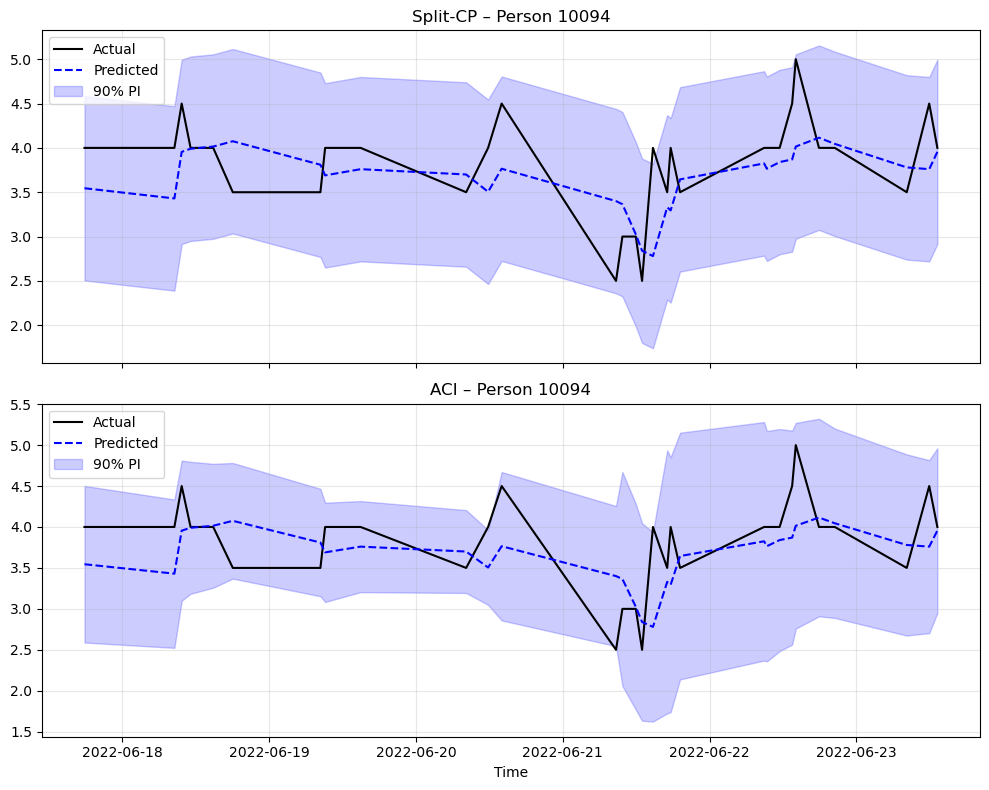


Person 43823:
  Split-CP    → MAE=1.172, Coverage=100.0%, Width=6.420, mae_cal:1.3258620689655174
  ACI         → MAE=1.172, Coverage=96.8%, Width=4.995,, mae_cal:1.3258620689655174


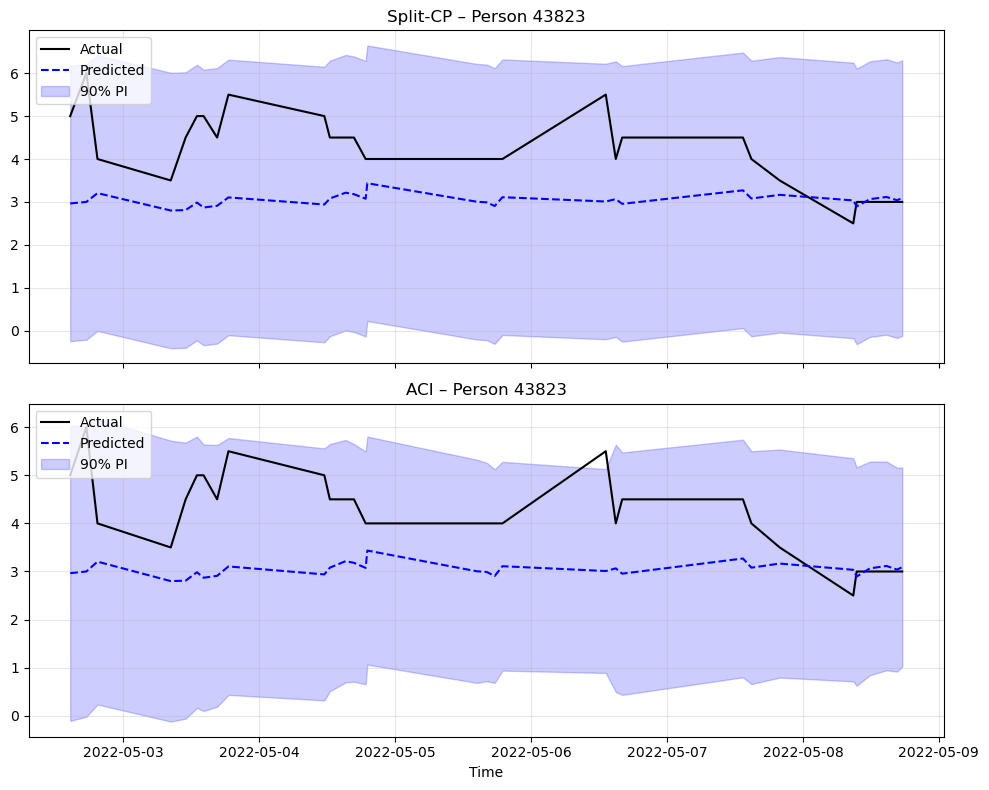


Person 43892:
  Split-CP    → MAE=0.723, Coverage=88.0%, Width=3.020, mae_cal:0.7082608695652174
  ACI         → MAE=0.723, Coverage=84.0%, Width=3.446,, mae_cal:0.7082608695652174


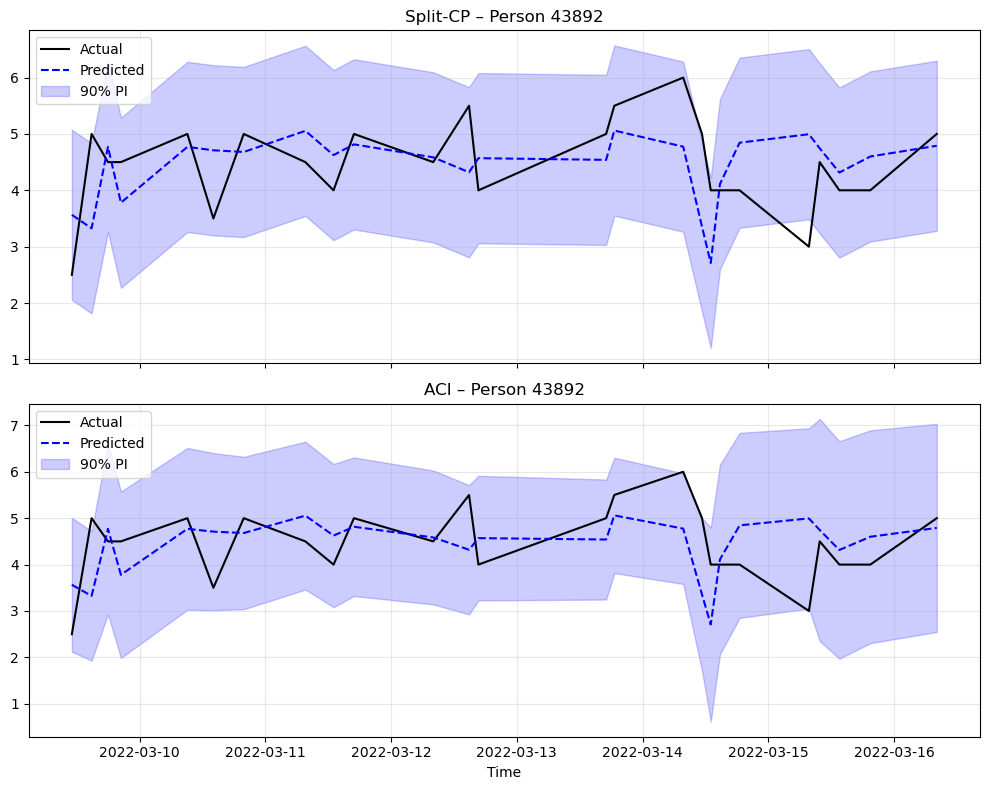


Person 56138.0:
  Split-CP    → MAE=1.022, Coverage=90.2%, Width=4.010, mae_cal:1.0053846153846155
  ACI         → MAE=1.022, Coverage=85.4%, Width=3.557,, mae_cal:1.0053846153846155


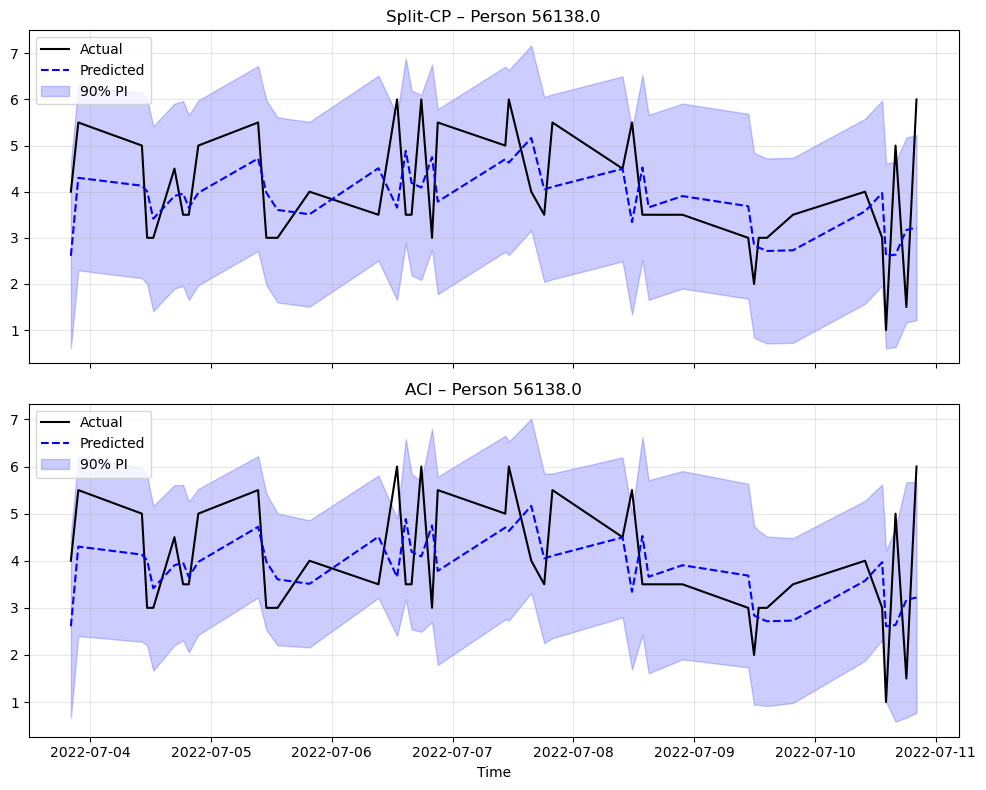

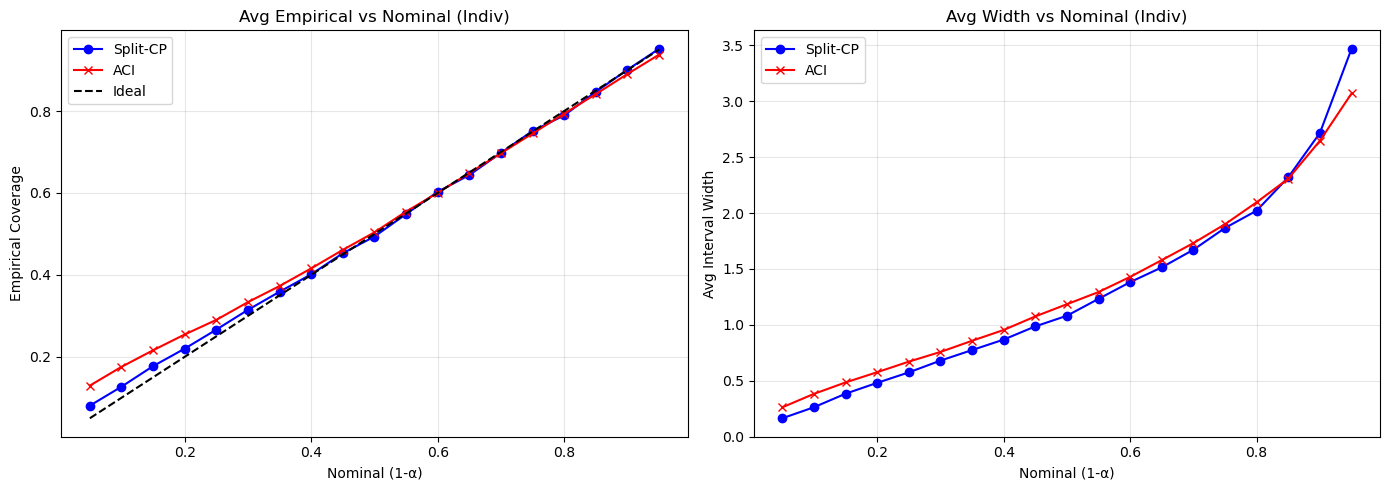

In [8]:
# Helper: manual ACI update for a given alpha & gamma
def manual_aci_intervals(preds, truths, cal_res, alpha, gamma):
    q = np.quantile(cal_res, 1-alpha)
    lo = np.empty_like(preds)
    up = np.empty_like(preds)
    for i, (yhat, ytrue) in enumerate(zip(preds, truths)):
        lo[i] = yhat - q
        up[i] = yhat + q
        miss = int(abs(ytrue - yhat) > q)       # 1=miss, 0=hit
        q += gamma * (miss - alpha)
        q = max(q, 0.0)
    return lo, up

# 1) Per-person plotting at α=0.10
alpha_plot = 0.10
gamma_aci = 0.5  # faster adaptation for small calib sets

for pid in plot_ids:
    df_tr_i  = df_train[ df_train["Name"]==pid ]
    df_cal_i = df_cal  [ df_cal  ["Name"]==pid ]
    df_te_i  = df_test [ df_test ["Name"]==pid ]
    if df_tr_i.empty or df_cal_i.empty or df_te_i.empty:
        continue

    # Extract per-person splits
    X_tr,  y_tr  = df_tr_i[FEATURE_COLS].values, df_tr_i[TARGET].values
    X_cal, y_cal = df_cal_i[FEATURE_COLS].values, df_cal_i[TARGET].values
    X_te,  y_te  = df_te_i[FEATURE_COLS].values, df_te_i[TARGET].values
    times = df_te_i["datetime"].values

    # Train per-person RF
    rf_i = RandomForestRegressor(n_estimators=100,
                                 random_state=42, n_jobs=-1)
    rf_i.fit(X_tr, y_tr)

    # --- Split-CP ---
    m_s = MapieRegressor(rf_i, method="plus", cv="prefit")
    m_s.fit(X_cal, y_cal)
    y_pred_s, pi_s = m_s.predict(X_te, alpha=alpha_plot)
    lo_s, up_s = pi_s[:,0,0], pi_s[:,1,0]


    # --- Improved ACI ---
    cal_res = np.abs(y_cal - rf_i.predict(X_cal))
    preds_a = rf_i.predict(X_te)
    lo_a, up_a = manual_aci_intervals(preds_a, y_te, cal_res,
                                      alpha_plot, gamma_aci)
    
    def compute_metrics(y_true, y_pred, lo, up):
        mae = mean_absolute_error(y_true, y_pred)
        cov = np.mean((y_true >= lo) & (y_true <= up))
        wid = np.mean(up - lo)
        return mae, cov, wid

    mae_s, cov_s, wid_s = compute_metrics(y_te, y_pred_s, lo_s, up_s)
    mae_a, cov_a, wid_a = compute_metrics(y_te, preds_a, lo_a, up_a)
    mae_cal = mean_absolute_error(y_cal, rf_i.predict(X_cal))
    
    print(f"\nPerson {pid}:")
    print(f"  Split-CP    → MAE={mae_s:.3f}, Coverage={cov_s:.1%}, Width={wid_s:.3f}, mae_cal:{mae_cal}")
    print(f"  ACI         → MAE={mae_a:.3f}, Coverage={cov_a:.1%}, Width={wid_a:.3f},, mae_cal:{mae_cal}")
    
    # Plot
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    for ax, (label, yp, lo, up) in zip(axes, [
        ("Split-CP",     y_pred_s, lo_s, up_s),        ("ACI", preds_a, lo_a, up_a),
    ]):
        ax.plot(times, y_te, "k-", label="Actual")
        ax.plot(times, yp,   "b--", label="Predicted")
        ax.fill_between(times, lo, up, color="b", alpha=0.2,
                        label="90% PI")
        ax.set_title(f"{label} – Person {pid}")
        ax.grid(alpha=0.3)
        ax.legend(loc="upper left")
    axes[-1].set_xlabel("Time")
    plt.tight_layout()
    plt.show()


# 2) Aggregate coverage & width across alphas for all individuals
emp_s, wid_s = [], []
emp_a, wid_a = [], []
mae_test=[]
mae_cal=[]

for alpha in alpha_list:
    cs, ws = [], []
    ca, wa = [], []


    for pid in df_feat["Name"].unique():
        df_tr_i  = df_train[ df_train["Name"]==pid ]
        df_cal_i = df_cal  [ df_cal  ["Name"]==pid ]
        df_te_i  = df_test [ df_test ["Name"]==pid ]
        if df_tr_i.empty or df_cal_i.empty or df_te_i.empty:
            continue

        X_tr,  y_tr  = df_tr_i[FEATURE_COLS].values, df_tr_i[TARGET].values
        X_cal, y_cal = df_cal_i[FEATURE_COLS].values, df_cal_i[TARGET].values
        X_te,  y_te  = df_te_i[FEATURE_COLS].values, df_te_i[TARGET].values

        # retrain per-person RF
        rf_i = RandomForestRegressor(n_estimators=100,
                                     random_state=42, n_jobs=-1)
        rf_i.fit(X_tr, y_tr)

        # Split-CP
        m_s = MapieRegressor(rf_i, method="plus", cv="prefit")
        m_s.fit(X_cal, y_cal)
        yp_s, pi_s = m_s.predict(X_te, alpha=alpha)
        lo_s, up_s = pi_s[:,0,0], pi_s[:,1,0]
        cs.append(np.mean((y_te>=lo_s)&(y_te<=up_s)))
        ws.append(np.mean(up_s - lo_s))

        # ACI
        cal_res = np.abs(y_cal - rf_i.predict(X_cal))
        yp_a    = rf_i.predict(X_te)
        lo_a, up_a = manual_aci_intervals(yp_a, y_te,
                                          cal_res, alpha, gamma_aci)
        ca.append(np.mean((y_te>=lo_a)&(y_te<=up_a)))
        wa.append(np.mean(up_a - lo_a))
        
        mae_test.append(mean_absolute_error(y_te, rf_i.predict(X_te)))
        mae_cal.append(mean_absolute_error(y_cal, rf_i.predict(X_cal)))
    
    emp_s.append(np.mean(cs)); wid_s.append(np.mean(ws))
    emp_a.append(np.mean(ca)); wid_a.append(np.mean(wa))
    
   
# 3) Plot aggregated Coverage & Width
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

ax1.plot(nominal_levels, emp_s, 'b-o', label="Split-CP")
ax1.plot(nominal_levels, emp_a, 'r-x', label="ACI")
ax1.plot(nominal_levels, nominal_levels,'k--',label="Ideal")
ax1.set(xlabel="Nominal (1-α)", ylabel="Empirical Coverage",
        title="Avg Empirical vs Nominal (Indiv)")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(nominal_levels, wid_s, 'b-o', label="Split-CP")
ax2.plot(nominal_levels, wid_a, 'r-x', label="ACI")
ax2.set(xlabel="Nominal (1-α)", ylabel="Avg Interval Width",
        title="Avg Width vs Nominal (Indiv)")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
